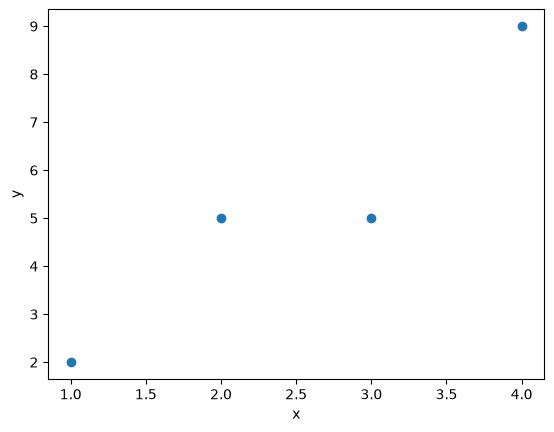

Parameter containing:
tensor([[-0.7234]], requires_grad=True)


In [14]:
import torch
import matplotlib.pyplot as plt

x = torch.tensor([[1.0],
                  [2.0],
                  [3.0],
                  [4.0]])

y = torch.tensor([[2.0],
                  [5.0],
                  [5.0],
                  [9.0]])

plt.scatter(x.squeeze(), y.squeeze())
plt.xlabel("x")
plt.ylabel("y")
plt.show()

# y = wx
model = torch.nn.Linear(
    in_features=1,
    out_features=1,
    bias=False
)

print(model.weight)

## train using 1 example at a time

In [15]:
loss_fn = torch.nn.MSELoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.05
)

for epoch in range(7):
    print("Round: " + str(epoch))
    for i in range(len(x)):

        # only ONE training example
        x_i = x[i:i+1]
        y_i = y[i:i+1]

        # prediction
        y_pred = model(x_i)

        # loss for this ONE example
        loss = loss_fn(y_pred, y_i)

        # backward + update
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        print(
            f"x={x_i.item():.0f}, "
            f"y={y_i.item():.0f}, "
            f"loss={loss.item():.3f}, "
            f"w={model.weight.item():.3f}"
        )

Round: 0
x=1, y=2, loss=7.417, w=-0.451
x=2, y=5, loss=34.834, w=0.729
x=3, y=5, loss=7.906, w=1.573
x=4, y=9, loss=7.335, w=2.656
Round: 1
x=1, y=2, loss=0.431, w=2.591
x=2, y=5, loss=0.033, w=2.554
x=3, y=5, loss=7.092, w=1.755
x=4, y=9, loss=3.913, w=2.547
Round: 2
x=1, y=2, loss=0.299, w=2.492
x=2, y=5, loss=0.000, w=2.495
x=3, y=5, loss=6.179, w=1.750
x=4, y=9, loss=4.008, w=2.550
Round: 3
x=1, y=2, loss=0.303, w=2.495
x=2, y=5, loss=0.000, w=2.497
x=3, y=5, loss=6.207, w=1.750
x=4, y=9, loss=4.005, w=2.550
Round: 4
x=1, y=2, loss=0.303, w=2.495
x=2, y=5, loss=0.000, w=2.497
x=3, y=5, loss=6.206, w=1.750
x=4, y=9, loss=4.005, w=2.550
Round: 5
x=1, y=2, loss=0.303, w=2.495
x=2, y=5, loss=0.000, w=2.497
x=3, y=5, loss=6.206, w=1.750
x=4, y=9, loss=4.005, w=2.550
Round: 6
x=1, y=2, loss=0.303, w=2.495
x=2, y=5, loss=0.000, w=2.497
x=3, y=5, loss=6.206, w=1.750
x=4, y=9, loss=4.005, w=2.550


Parameter containing:
tensor([[2.5502]], requires_grad=True)


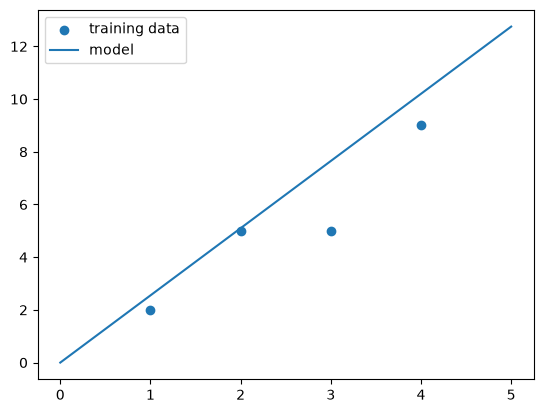

In [3]:
model.eval()
print(model.weight)

x_line = torch.linspace(0, 5, 100).reshape(-1, 1)

with torch.no_grad():
    y_line = model(x_line)

plt.scatter(x.squeeze(), y.squeeze(), label="training data")
plt.plot(x_line.squeeze(), y_line.squeeze(), label="model")
plt.legend()
plt.show()

## Batch!!

In [5]:
model_batch = torch.nn.Linear(
    in_features=1,
    out_features=1,
    bias=False
)

print(model_batch.weight)
print()
print()

loss_fn = torch.nn.MSELoss()

optimizer = torch.optim.SGD(
    model_batch.parameters(),
    lr=0.05
)


for epoch in range(7):
    # 1. prediction
    y_pred = model_batch(x)

    # 2. loss
    loss = loss_fn(y_pred, y)

    # 3. calculate gradients
    optimizer.zero_grad()
    loss.backward()

    # 4. update parameters
    optimizer.step()

    print(
        f"epoch={epoch:2d}  "
        f"loss={loss.item():.4f}  "
        f"w={model_batch.weight.item():.4f}"
    )

Parameter containing:
tensor([[-0.5569]], requires_grad=True)


epoch= 0  loss=53.6202  w=1.4358
epoch= 1  loss=3.9841  w=1.9339
epoch= 2  loss=0.8818  w=2.0585
epoch= 3  loss=0.6879  w=2.0896
epoch= 4  loss=0.6758  w=2.0974
epoch= 5  loss=0.6751  w=2.0994
epoch= 6  loss=0.6750  w=2.0998


model weight=2.5502
model_batch weight=2.0998


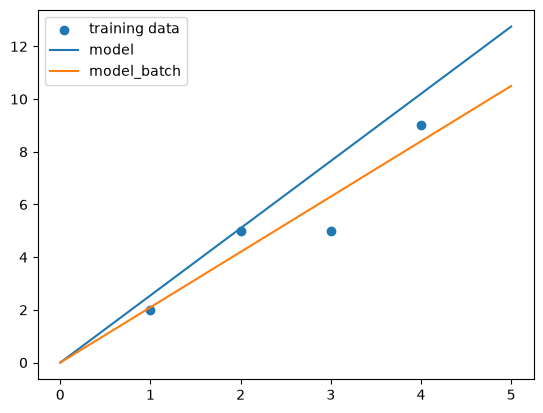

In [7]:
model.eval()
model_batch.eval()
print(f"model weight={model.weight.item():.4f}")
print(f"model_batch weight={model_batch.weight.item():.4f}")

x_line = torch.linspace(0, 5, 100).reshape(-1, 1)

with torch.no_grad():
    y_line_model = model(x_line)
    y_line_batch = model_batch(x_line)

plt.scatter(
    x.squeeze(),
    y.squeeze(),
    label="training data"
)

plt.plot(
    x_line.squeeze(),
    y_line_model.squeeze(),
    label="model"
)

plt.plot(
    x_line.squeeze(),
    y_line_batch.squeeze(),
    label="model_batch"
)

plt.legend()
plt.show()